In [36]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

In [38]:
df = pd.read_csv('https://drive.google.com/uc?export=download&id=16Hwh3nZyQ274UyUSkvex9l9UxCxJHBj3')

# Part I: Exploratory Data Analysis (EDA)

## Problem 1: Data Loading

Q1. Dataset Dimensions

In [39]:
print(f'Number of columns = {len(df.columns)}, Number of Rows = {len(df)}')

Number of columns = 12, Number of Rows = 891


Q2: Summary Statistics

In [40]:
# Q2: Summary Statistics

# Select relevant numerical columns
num_cols = ["Age", "Fare", "SibSp", "Parch"]

# Compute summary statistics
summary = df[num_cols].describe()
summary

,Age,Fare,SibSp,Parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [41]:
select_df = df[['Age', 'Fare', 'SibSp', 'Parch']]

In [42]:
print(f"Median of Fare: {np.median(select_df['Fare'])}")

Median of Fare: 14.4542


In [43]:
# Q3: Missing Data

# Total rows
n_rows = len(df)

# Count missing values per column
missing_counts = df.isna().sum()

# Percentage of missing values per column
missing_percent = (missing_counts / n_rows) * 100

# Build a summary table
missing_table = (
    pd.DataFrame({
        "Variable": missing_counts.index,
        "Missing Count": missing_counts.values,
        "Missing Percent": missing_percent.values
    })
    .sort_values("Missing Count", ascending=False)
)
missing_table_nonzero = missing_table[missing_table["Missing Count"] > 0]

missing_table_nonzero



,Variable,Missing Count,Missing Percent
10,Cabin,687,77.104377
5,Age,177,19.865320
11,Embarked,2,0.224467


In [44]:
n_rows

891

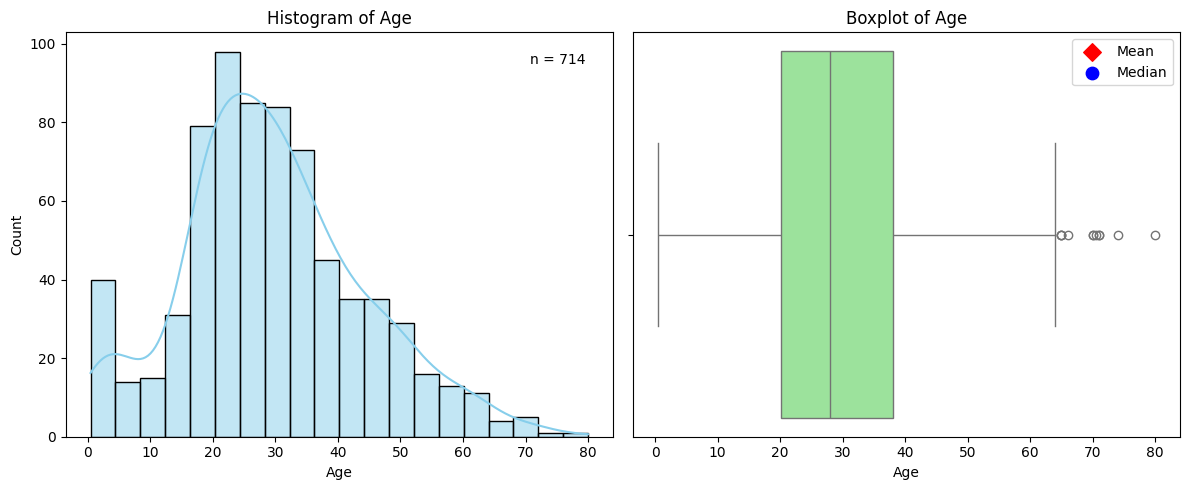

In [45]:
# Q4: Univariate Analysis — Age
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
sns.histplot(df["Age"].dropna(), kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Histogram of Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].text(0.95, 0.95, f"n = {df['Age'].notna().sum()}",
             transform=axes[0].transAxes, ha="right", va="top")

# Boxplot with mean and median marker
sns.boxplot(x=df["Age"], ax=axes[1], color="lightgreen")
mean_age = df["Age"].mean()
axes[1].scatter(mean_age, 0.06, marker="D", color="red", s=80, label="Mean")
median_age = df["Age"].median()
axes[1].scatter(median_age, -0.06, marker="o", color="blue", s=80, label="Median")
axes[1].set_title("Boxplot of Age")
axes[1].set_xlabel("Age")
axes[1].legend()
plt.tight_layout()
plt.show()

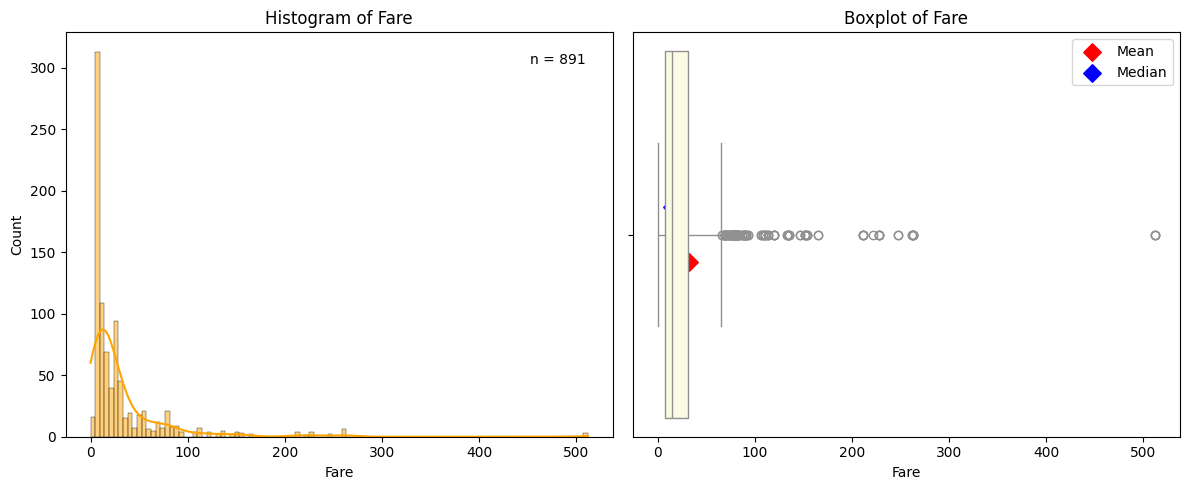

In [46]:
# Q4: Univariate Analysis — Fare
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
sns.histplot(df["Fare"].dropna(), kde=True, ax=axes[0], color="orange")
axes[0].set_title("Histogram of Fare")
axes[0].set_xlabel("Fare")
axes[0].set_ylabel("Count")
axes[0].text(0.95, 0.95, f"n = {df['Fare'].notna().sum()}",
             transform=axes[0].transAxes, ha="right", va="top")

# Boxplot with mean marker
sns.boxplot(x=df["Fare"], ax=axes[1], color="lightyellow")
mean_fare = df["Fare"].mean()
axes[1].scatter(mean_fare, 0.06, marker="D", color="red", s=80, label="Mean")
median_fare = df["Fare"].median()
axes[1].scatter(median_fare, -0.06, marker="D", color="blue", s=80, label="Median")
axes[1].legend()
axes[1].set_title("Boxplot of Fare")
axes[1].set_xlabel("Fare")

plt.tight_layout()
plt.show()

In [47]:
median_fare

14.4542

/tmp/ipython-input-2205712815.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Pclass"], palette="pastel")


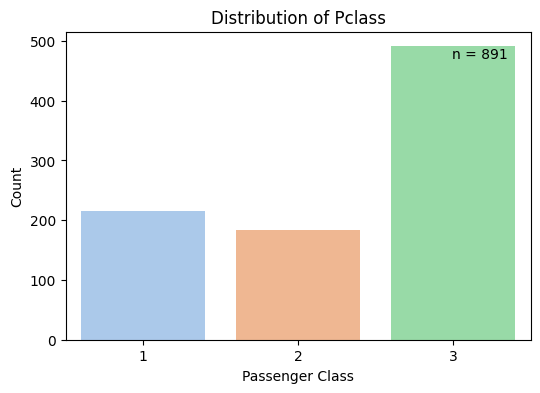

In [48]:
# Q4: Univariate Analysis — Pclass
plt.figure(figsize=(6,4))
sns.countplot(x=df["Pclass"], palette="pastel")
plt.title("Distribution of Pclass")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.text(0.95, 0.95, f"n = {df['Pclass'].notna().sum()}",
         transform=plt.gca().transAxes, ha="right", va="top")
plt.show()

/tmp/ipython-input-2951285462.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Sex"], palette="Set2")


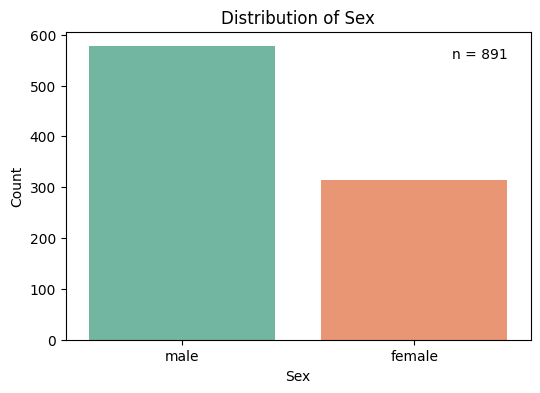

In [49]:
# Q4: Univariate Analysis — Sex
plt.figure(figsize=(6,4))
sns.countplot(x=df["Sex"], palette="Set2")
plt.title("Distribution of Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.text(0.95, 0.95, f"n = {df['Sex'].notna().sum()}",
         transform=plt.gca().transAxes, ha="right", va="top")
plt.show()

/tmp/ipython-input-4143270828.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Embarked"], palette="Set3")


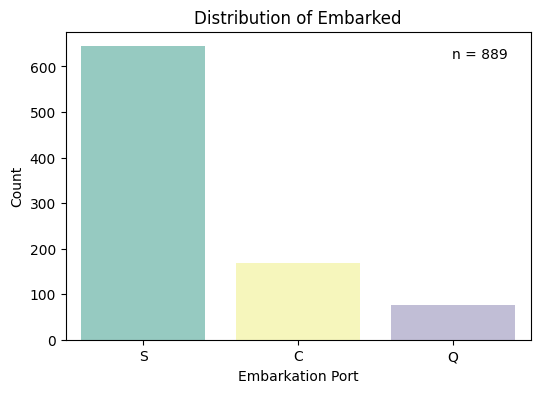

In [50]:
# Q4: Univariate Analysis — Embarked
plt.figure(figsize=(6,4))
sns.countplot(x=df["Embarked"], palette="Set3")
plt.title("Distribution of Embarked")
plt.xlabel("Embarkation Port")
plt.ylabel("Count")
plt.text(0.95, 0.95, f"n = {df['Embarked'].notna().sum()}",
         transform=plt.gca().transAxes, ha="right", va="top")
plt.show()

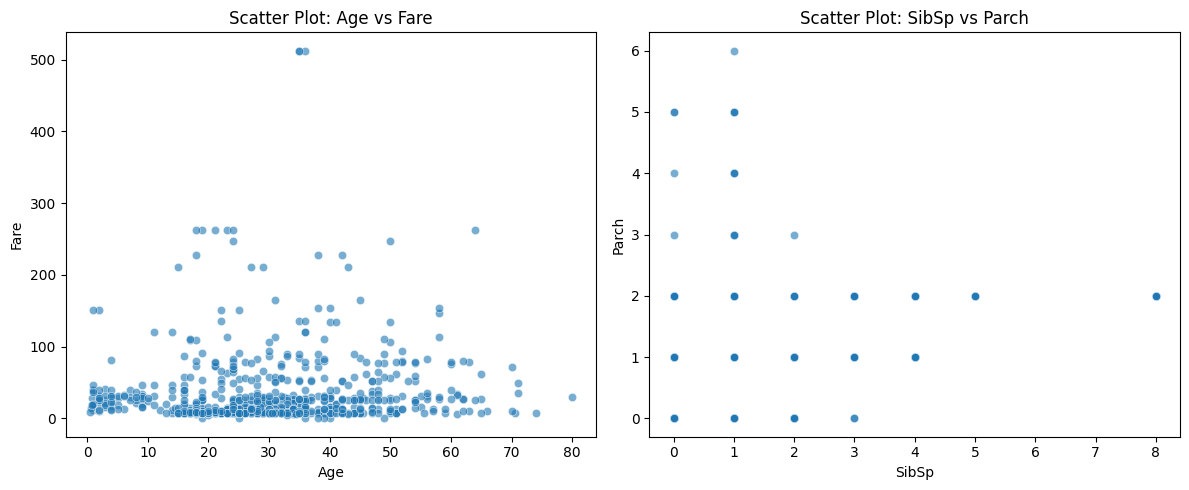

In [51]:
# Q5: Bivariate Analysis — Scatter Plots

plt.figure(figsize=(12,5))

# Age vs Fare
plt.subplot(1,2,1)
sns.scatterplot(x=df["Age"], y=df["Fare"], alpha=0.6)
plt.title("Scatter Plot: Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

# SibSp vs Parch
plt.subplot(1,2,2)
sns.scatterplot(x=df["SibSp"], y=df["Parch"], alpha=0.6)
plt.title("Scatter Plot: SibSp vs Parch")
plt.xlabel("SibSp")
plt.ylabel("Parch")

plt.tight_layout()
plt.show()

Spearman Correlation Matrix:


,Age,Fare,SibSp,Parch
Age,1.000000,0.135051,-0.182061,-0.254212
Fare,0.135051,1.000000,0.447113,0.410074
SibSp,-0.182061,0.447113,1.000000,0.450014
Parch,-0.254212,0.410074,0.450014,1.000000


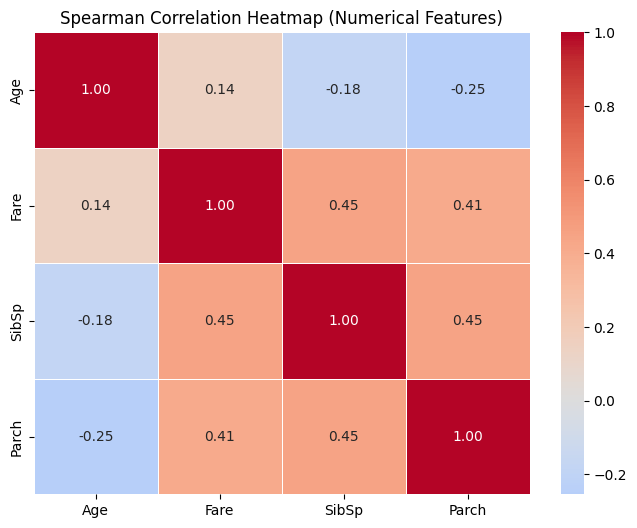

In [52]:
# Q5: Spearman Correlation Matrix & Heatmap

# Choose numerical features only
num_cols = ["Age", "Fare", "SibSp", "Parch"]

# Compute Spearman correlation
spearman_corr = df[num_cols].corr(method="spearman")

# Display correlation matrix
print("Spearman Correlation Matrix:")
display(spearman_corr)

# Heatmap with annotations
plt.figure(figsize=(8,6))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white"
)
plt.title("Spearman Correlation Heatmap (Numerical Features)")
plt.show()

Total female passengers: 314


/tmp/ipython-input-2244386060.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


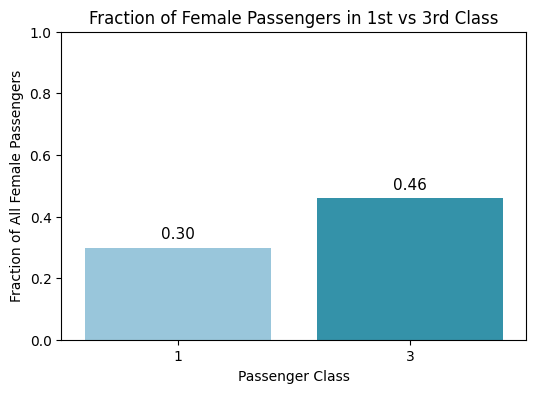

In [53]:
# Q6: Multivariate / Grouped Analysis (corrected)

# All female passengers
female_df = df[df["Sex"] == "female"]
total_females = len(female_df)
print("Total female passengers:", total_females)

# Counts of females by class
female_class_counts = female_df["Pclass"].value_counts().sort_index()
female_class_counts
# Fractions of all female passengers in each class
female_class_fraction = female_class_counts / total_females
female_class_fraction
# Keep only 1st and 3rd class fractions for the bar chart
female_1_3_fraction = female_class_fraction[[1, 3]]
female_1_3_fraction
plt.figure(figsize=(6,4))
sns.barplot(
    x=female_1_3_fraction.index.astype(str),
    y=female_1_3_fraction.values,
    palette=["#8ecae6", "#219ebc"]
)

plt.title("Fraction of Female Passengers in 1st vs 3rd Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fraction of All Female Passengers")
plt.ylim(0, 1)

# Add labels on bars
for i, v in enumerate(female_1_3_fraction.values):
    plt.text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=11)

plt.show()

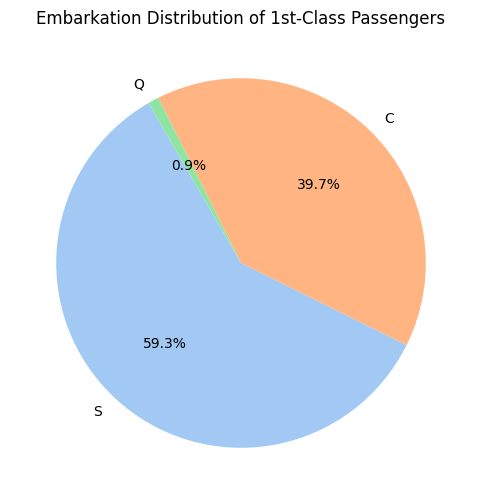

In [54]:
# Second grouped analysis (Q6): Embarkation distribution of 1st-class passengers

# Filter 1st-class passengers
first_class_df = df[df["Pclass"] == 1]

# Count embarkation ports
embark_counts = first_class_df["Embarked"].value_counts(dropna=True)
embark_counts
plt.figure(figsize=(6,6))
plt.pie(
    embark_counts.values,
    labels=embark_counts.index,
    autopct="%1.1f%%",
    startangle=120,
    colors=sns.color_palette("pastel")
)

plt.title("Embarkation Distribution of 1st-Class Passengers")
plt.show()

In [55]:
# === Problem 3: Dimensionality Reduction with PCA and t-SNE ===
# Q7: Preprocessing pipeline with KNN imputation

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Drop non-quantitative / identifier columns
cols_drop = ["PassengerId", "Name", "Ticket", "Cabin"]
df_dim = df.drop(columns=cols_drop)

# 2. Convert categorical features (Sex, Embarked) to numeric via one-hot encoding
df_proc = pd.get_dummies(df_dim, columns=["Sex", "Embarked"], drop_first=True)

# df_proc now has columns:
# ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']

# 3. KNN imputation on Age
features_for_impute = df_proc.drop(columns=["Survived"])
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(features_for_impute)

# Wrap back into a DataFrame
X_imputed_df = pd.DataFrame(
    X_imputed,
    columns=features_for_impute.columns,
    index=df_proc.index
)

# 4. Final preprocessed dataset for PCA / t-SNE
df_pca_base = X_imputed_df.copy()
df_pca_base["Survived"] = df_proc["Survived"].values
print("Shape after preprocessing:", df_pca_base.shape)
print("Total missing values remaining:", df_pca_base.isna().sum().sum())

Shape after preprocessing: (891, 9)
Total missing values remaining: 0


In [56]:
# === Q8–Q10: PCA with all components ===

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Separate features (X) and label (y)
feature_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare", "Sex_male", "Embarked_Q", "Embarked_S"]
X = df_pca_base[feature_cols].values
y = df_pca_base["Survived"].values

# 2. Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA with n_components=None → keep all components
pca = PCA(n_components=None, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cum_explained = explained.cumsum()

print("Explained variance ratio:", explained)
print("Cumulative explained variance:", cum_explained)

Explained variance ratio: [0.22979532 0.2156842  0.19343683 0.10716371 0.09007955 0.06993608
 0.05151006 0.04239425]
Cumulative explained variance: [0.22979532 0.44547952 0.63891635 0.74608006 0.83615961 0.90609569
 0.95760575 1.        ]


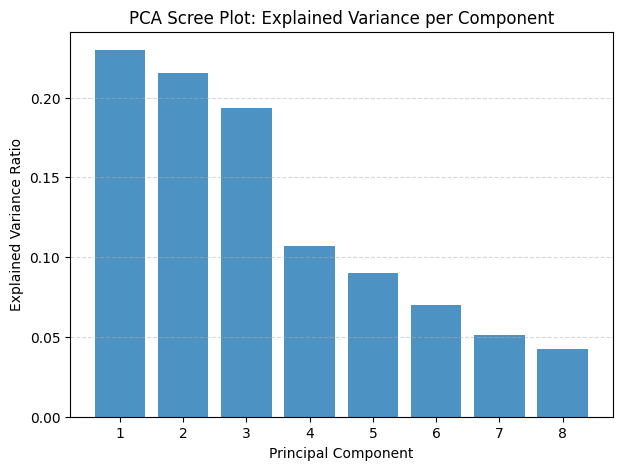

In [57]:
# Q9 - Scree plot: per-component explained variance

indices = np.arange(1, len(explained) + 1)

plt.figure(figsize=(7,5))
plt.bar(indices, explained, alpha=0.8)
plt.xticks(indices)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot: Explained Variance per Component")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

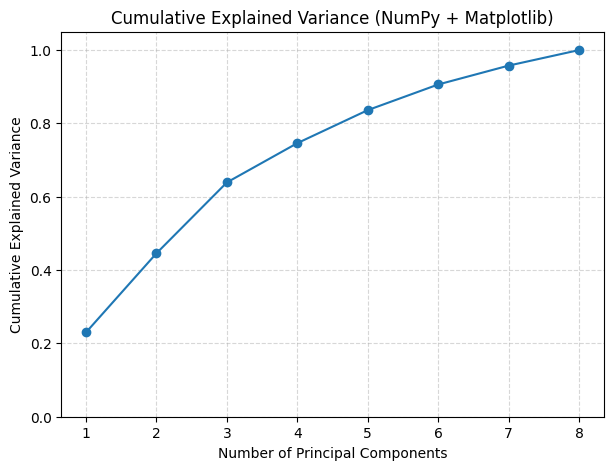

In [58]:
# Q10 - Cumulative Explained Variance using NumPy + Matplotlib

import numpy as np
import matplotlib.pyplot as plt

indices = np.arange(1, len(cum_explained) + 1)

plt.figure(figsize=(7,5))
plt.plot(indices, cum_explained, marker="o", linestyle="-")
plt.xticks(indices)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance (NumPy + Matplotlib)")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

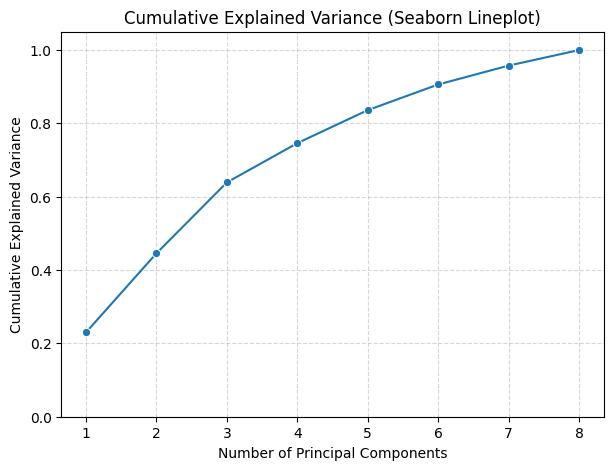

In [59]:
# Q10 - Cumulative Explained Variance using Seaborn

import seaborn as sns

plt.figure(figsize=(7,5))
sns.lineplot(x=indices, y=cum_explained, marker="o")
plt.xticks(indices)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance (Seaborn Lineplot)")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

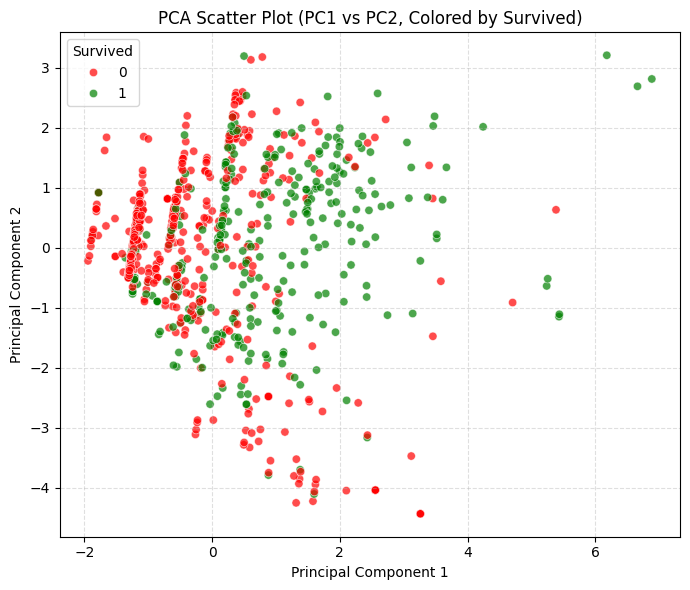

In [60]:
# === Q11: PCA Scatter Plot (PC1 vs PC2, colored by Survived) ===

# Build a DataFrame for plotting PC1 vs PC2
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Survived": y
})

# Scatter plot of PC1 vs PC2, colored by Survived
plt.figure(figsize=(7,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Survived",
    palette={0: "red", 1: "green"},
    alpha=0.7
)

plt.title("PCA Scatter Plot (PC1 vs PC2, Colored by Survived)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Survived")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


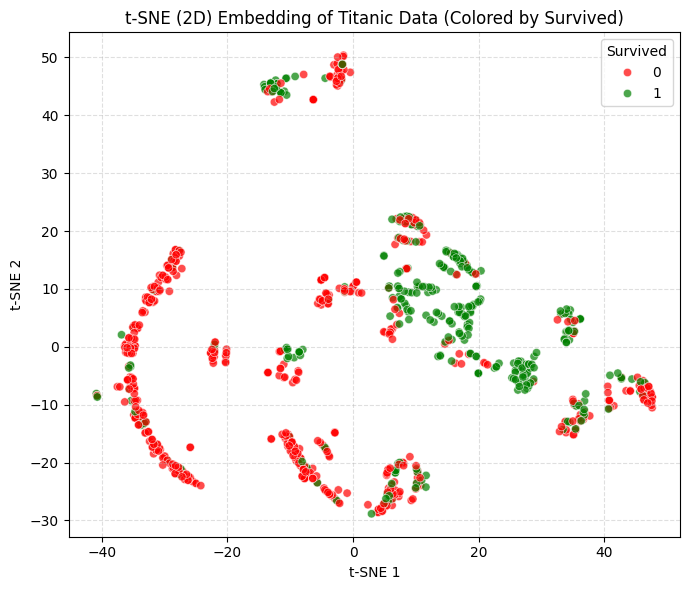

In [61]:
# Apply t-SNE for 2D embedding

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)


# Build DataFrame for plotting

tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "Survived": y
})


# Plot t-SNE embedding with seaborn.scatterplot

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="Survived",
    palette={0: "red", 1: "green"},
    alpha=0.7
)

plt.title("t-SNE (2D) Embedding of Titanic Data (Colored by Survived)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Survived")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [62]:
!pip freeze > requirements.txt

In [63]:
pip freeze > requirements.txt